In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


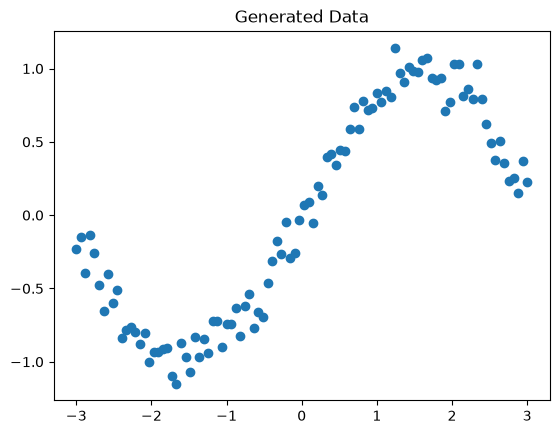

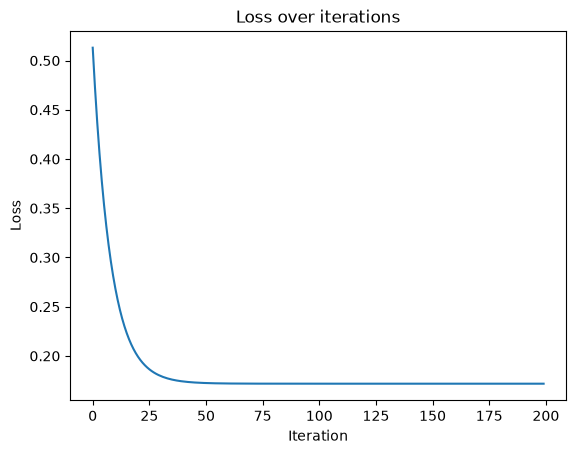

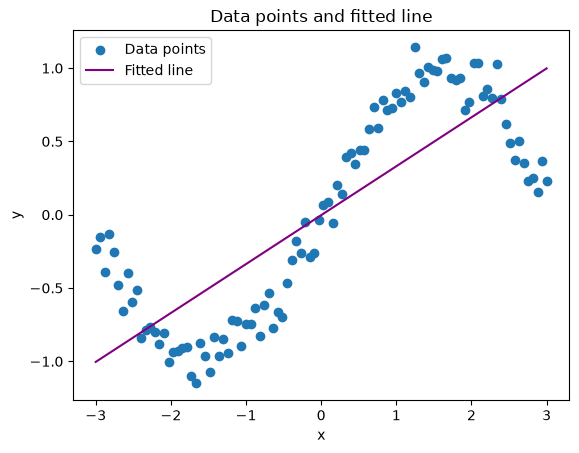

In [12]:
# Section 1: Inside a Neural Network

# Generatex values
x = np.linspace(-3, 3, 100)

# Generate random noise
noise = np.random.normal(0, 0.1, 100)

# Generate y values + noise
y = np.sin(x) + noise

# plotting
plt.scatter(x, y, label="Data points")
plt.title("Generated Data")
plt.show()

# Initializing the weight and bias
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01

# Implementing one gradient descent step
lr = 0.01
losses = []


for step in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)  # Mean squared error
    losses.append(loss)

    # Calculating gradients
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # Updating weights and bias
    w = w - lr * dw
    b = b - lr * db

# Plotting the loss curve over 200 steps
plt.plot(losses)
plt.title("Loss over iterations")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

# Plotting the data with the fitted line top
y_hat = w * x + b
plt.scatter(x, y, label="Data points")
plt.plot(x, y_hat, color="purple", label="Fitted line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Data points and fitted line")
plt.legend()
plt.show()


Student Reasoning
1.
2.

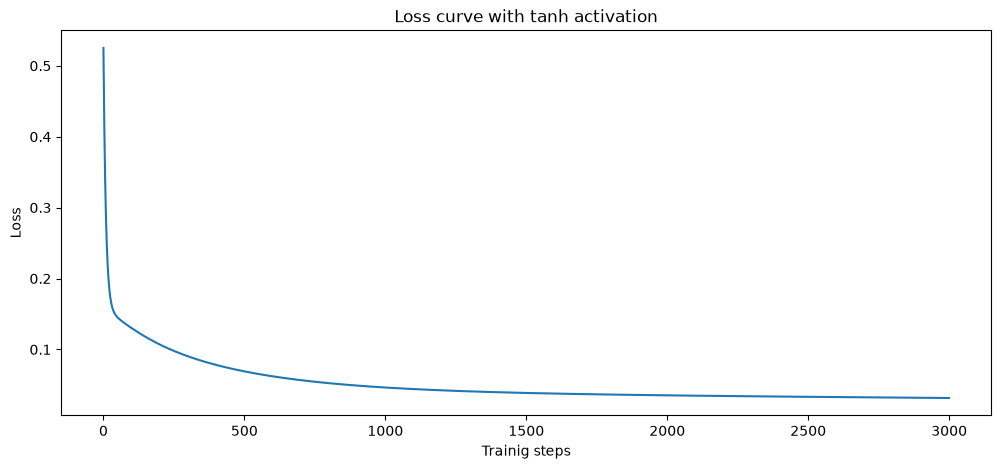

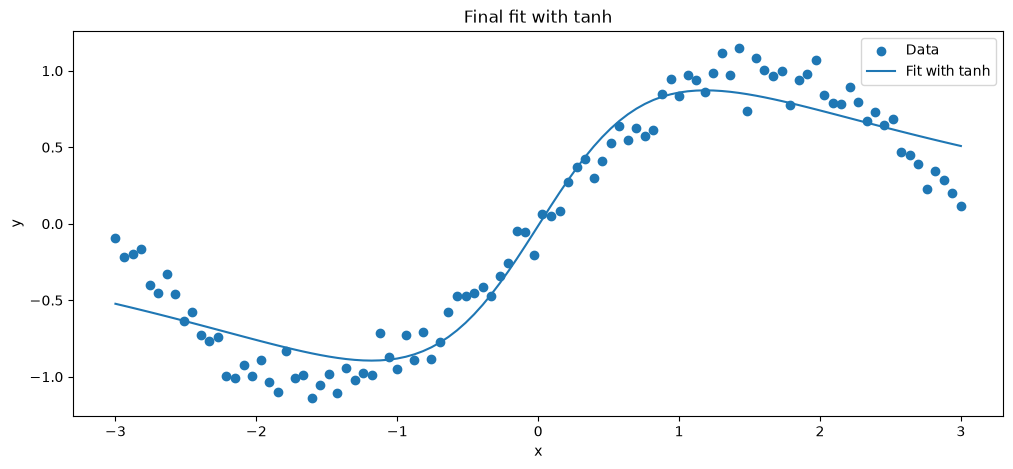

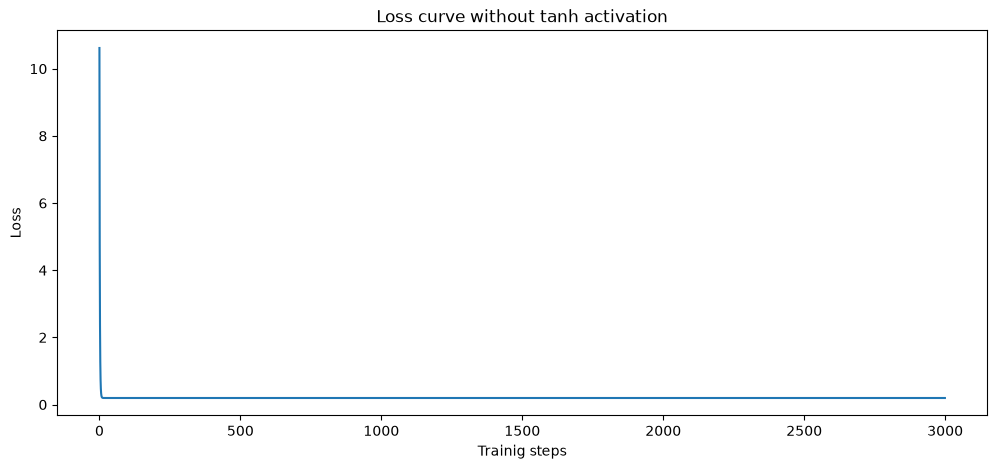

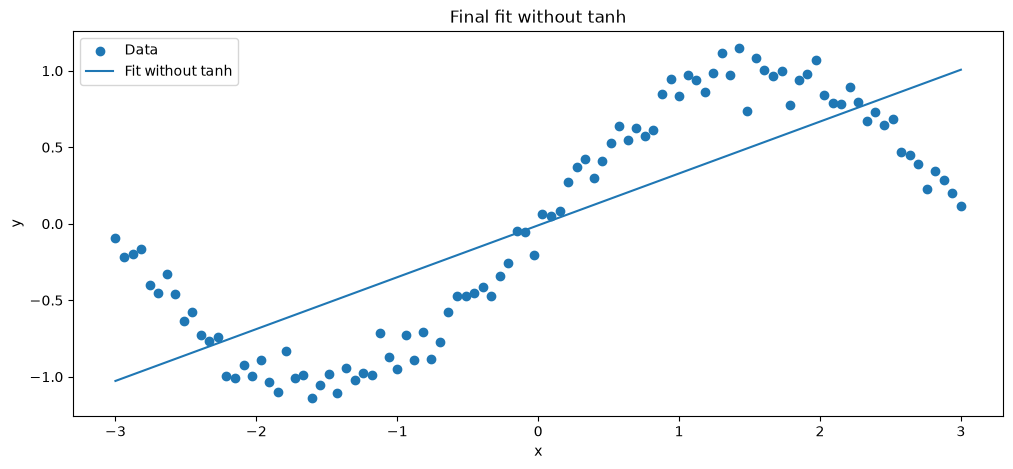

In [11]:
# Hidden layers and activations

# Reshaping x and y
x = x.reshape(-1,1)
y=y.reshape(-1,1)

# Initializing the weights and biases
W1 = np.random.randn(1,8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8,1) * 0.5
b2 = np.zeros(1)

lr = 0.01
steps = 3000
losses = []

# Forward pass
z1 = x @ W1 + b1
h = np.tanh(z1)
y_hat = h @ W2 + b2
loss = np.mean((y_hat - y)  ** 2)

# Backward pass
d_yhat = 2 * (y_hat -y) / len(y)
dW2 = h.T @ d_yhat
db2 = d_yhat.sum(axis = 0)
dh = d_yhat @ W2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)
dW1 = x.T @ dz1
db1 = dz1.sum(axis = 0)

# Updating all parameters
for step in range(steps):
    # Forward pass
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y)  ** 2)
    losses.append(loss)

    # Backward pass
    d_yhat = 2 * (y_hat -y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis = 0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis = 0)

    # Updating the parameters
    W1 -= lr * dW1
    b1 -= lr * db1

    W2 -= lr * dW2
    b2 -= lr * db2

# Plotting the loss curve and final fit over the data
plt.figure(figsize=(12, 5))
plt.plot(losses)
plt.title("Loss curve with tanh activation")
plt.xlabel("Trainig steps")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(12, 5))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, label="Fit with tanh")
plt.title("Final fit with tanh")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


# Re-run without non linear activation
W1_linear = np.random.randn(1, 8) * 0.5
b1_linear = np.zeros(8)

W2_linear = np.random.randn(8, 1) * 0.5
b2_linear = np.zeros(1)

linear_losses = []

for step in range(3000):

    # Forward pass without tanh
    z1 = x @ W1_linear + b1_linear
    h = z1
    y_hat_linear = h @ W2_linear + b2_linear

    loss = np.mean((y_hat_linear - y) ** 2)
    linear_losses.append(loss)

    # Backward pass
    d_yhat = 2 * (y_hat_linear - y) / len(y)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2_linear.T

    # No tanh, so derivative is 1
    dz1 = dh

    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update parameters
    W1_linear -= lr * dW1
    b1_linear -= lr * db1
    W2_linear -= lr * dW2
    b2_linear -= lr * db2

# Plotting the loss curve and final fit over the data
plt.figure(figsize=(12, 5))
plt.plot(linear_losses)
plt.title("Loss curve without tanh activation")
plt.xlabel("Trainig steps")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(12, 5))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat_linear, label="Fit without tanh")
plt.title("Final fit without tanh")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# Observation: With the tanh activation function , the network was able to learn the no linear sine wave pattern and produced a curved fit which almost matched the data but when the tanh activation was removed, the network produced a straight line fit which did not match the data at all.This shows that non linear activation functions are important because without them multiple layers are equal to a single linear model.





In [13]:
# Section 2.1- Preprocess and split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import OrdinalEncoder

# Loading the dataset
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)

# Encoding categorical variables
binary_cols = ["family_history_with_overweight","FAVC","SMOKE","SCC"]
for col in binary_cols:
    obesity[col] = obesity[col].map({"yes" : 1,"no": 0})

# Encoding Gender
obesity["Gender"]= obesity["Gender"].map({"Female": 0, "Male": 1})

# Encoding CAEC and CALC
ordinal_cols = ["CAEC", "CALC"]
encoder = OrdinalEncoder()
obesity[ordinal_cols] = encoder.fit_transform(obesity[ordinal_cols])

# Encoding MTRANS
obesity = pd.get_dummies(obesity, columns = ["MTRANS"], drop_first = True)

# Encoding the target variable
label_e = LabelEncoder()
obesity["NObeyesdad"]= label_e.fit_transform(obesity["NObeyesdad"])

# Splitting the dataset into features and target variable
X = obesity.drop("NObeyesdad", axis=1)
y = obesity["NObeyesdad"]

# 60/20/20 split for training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.4, stratify = y, random_state = RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, stratify = y_temp, random_state = RANDOM_STATE)


# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Converting to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Creating DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)



In [ ]:
# Part 2.2- Design the network
import torch.nn as nn

class FeedForwardNet(nn.Module):
    def __init__(self,input_dim, hidden_sizes=(64, 32), n_classes = 7):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_sizes[0]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[1], n_classes)
        )
    def forward(self,x):
        return self.network(x)

# Instantiating the model
input_dim = X_train_tensor.shape[1]

model = FeedForwardNet(input_dim=input_dim, hidden_sizes = (64,32), n_classes = 7).to(DEVICE)
print(model)


# Count trainable parameter
trainable_parameter = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total trainable parameters:", trainable_parameter)

first_layer_parameter = input_dim * 64 + 64
print("First layer parameters:", first_layer_parameter)



    
    


FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Total trainable parameters: 3591
FIrst layer parameters: 1280


Epoch 01/ 50 | Train Loss:  0.144966 | Val Loss: 0.4128 | Train Accuracy: 0.9724 | Val Accuracy: 0.8934
Epoch 02/ 50 | Train Loss:  0.134412 | Val Loss: 0.4094 | Train Accuracy: 0.9724 | Val Accuracy: 0.8886
Epoch 03/ 50 | Train Loss:  0.120312 | Val Loss: 0.4144 | Train Accuracy: 0.9810 | Val Accuracy: 0.8934
Epoch 04/ 50 | Train Loss:  0.110322 | Val Loss: 0.4102 | Train Accuracy: 0.9818 | Val Accuracy: 0.8957
Epoch 05/ 50 | Train Loss:  0.100696 | Val Loss: 0.4141 | Train Accuracy: 0.9834 | Val Accuracy: 0.8910
Epoch 06/ 50 | Train Loss:  0.093263 | Val Loss: 0.4104 | Train Accuracy: 0.9874 | Val Accuracy: 0.8886
Epoch 07/ 50 | Train Loss:  0.086904 | Val Loss: 0.4264 | Train Accuracy: 0.9866 | Val Accuracy: 0.8863
Epoch 08/ 50 | Train Loss:  0.078657 | Val Loss: 0.4224 | Train Accuracy: 0.9889 | Val Accuracy: 0.8910
Epoch 09/ 50 | Train Loss:  0.072637 | Val Loss: 0.4247 | Train Accuracy: 0.9897 | Val Accuracy: 0.8910
Epoch 10/ 50 | Train Loss:  0.070515 | Val Loss: 0.4355 | Train 

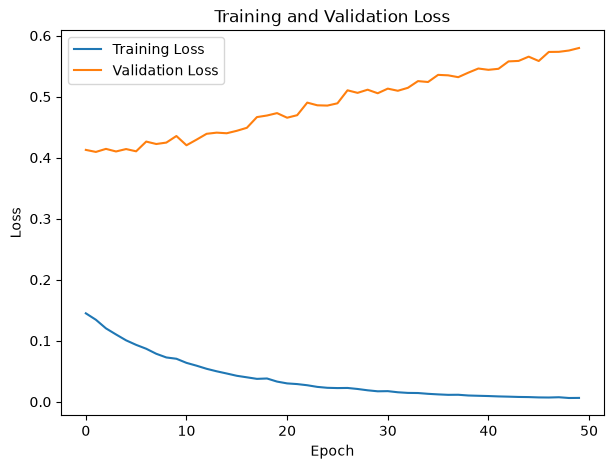

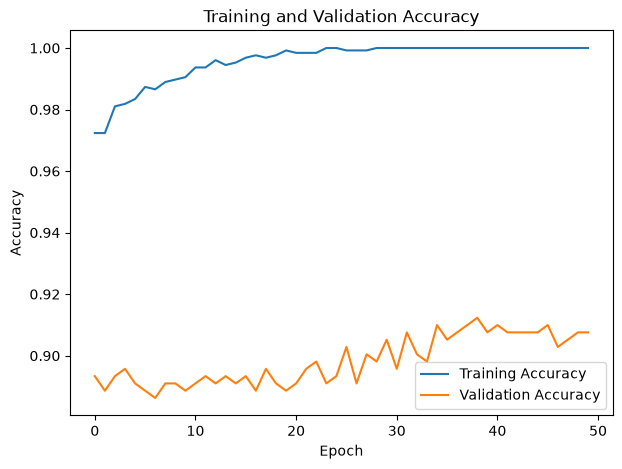

In [19]:
# Section 2.3- The training loop
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

num_epochs = 50

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0

for epoch in range(num_epochs):
    model.train()

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

    model.eval()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for xb,yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)

            train_loss += loss.item() * xb.size(0)
            predictions = torch.argmax(logits, dim=1)

            train_correct += (predictions == yb).sum().item()
            train_total += yb.size(0)

        for xb,yb in val_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)

            val_loss += loss.item() * xb.size(0)
            predictions = torch.argmax(logits, dim=1)

            val_correct += (predictions == yb).sum().item()
            val_total += yb.size(0)

    # Average loss and accuracy
    train_loss = train_loss / train_total
    val_loss = val_loss / val_total

    train_accuracy = train_correct / train_total
    val_accuracy = val_correct / val_total

    # Store history
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    # Saving the model
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), "ffn_best.pt")

    # Printing epoch summary
    print(
        f"Epoch {epoch + 1:02d}/ {num_epochs} | "
        f"Train Loss: {train_loss : 4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

# Plotting the loss curve
plt.figure(figsize=(7,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

# Plotting the accuracy curve
plt.figure(figsize = (7,5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()


    




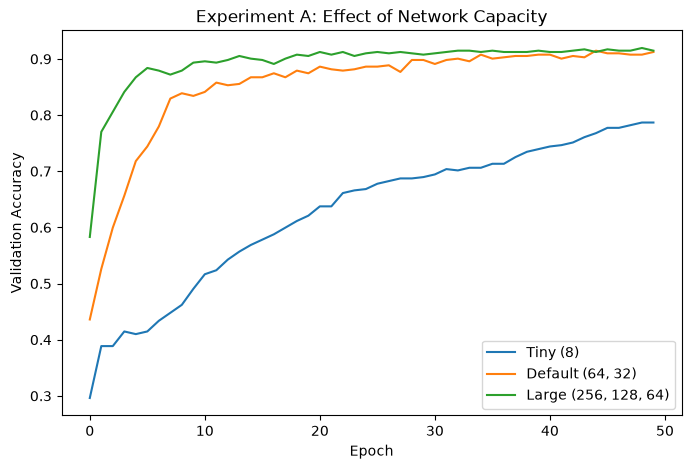

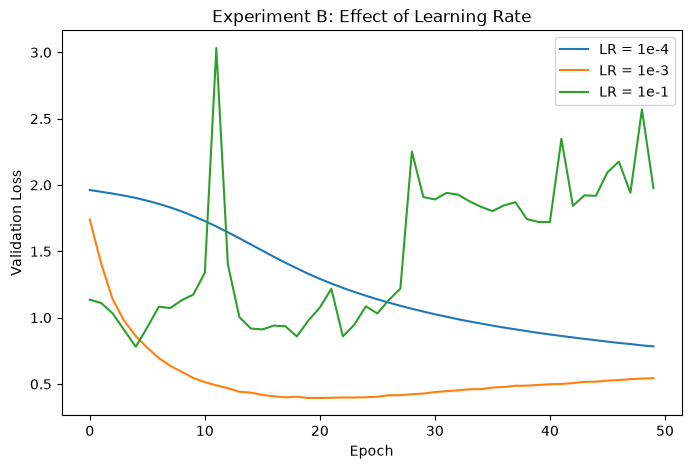

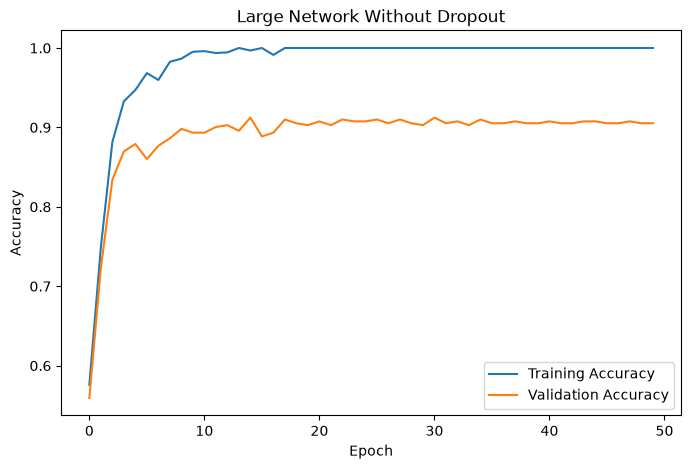

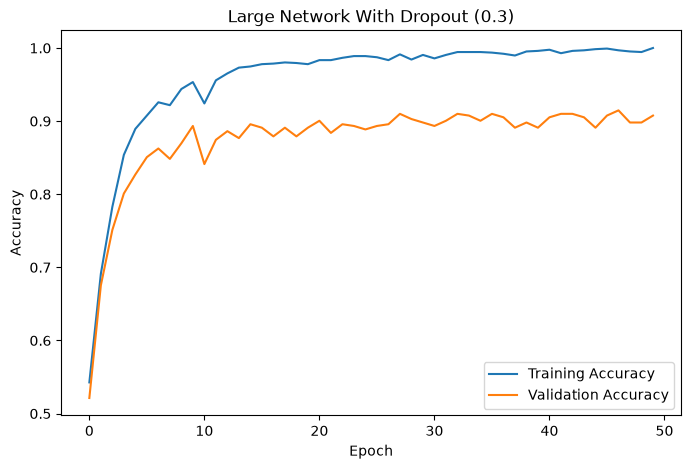

In [22]:
# Section 2.4 - Experiments

class FeedForwardNet(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_sizes=(64, 32),
        n_classes=7,
        dropout=0.0
    ):
        super().__init__()

        layers = []
        current_dim = input_dim

        for hidden_dim in hidden_sizes:
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            current_dim = hidden_dim

        layers.append(nn.Linear(current_dim, n_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# Experiment function
def run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
):
    experiment_train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    experiment_val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    experiment_model = FeedForwardNet(
        input_dim=input_dim,
        hidden_sizes=hidden_sizes,
        n_classes=7,
        dropout=dropout
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        experiment_model.parameters(),
        lr=lr
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    for epoch in range(epochs):

        # Training
        experiment_model.train()

        for xb, yb in experiment_train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            logits = experiment_model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

        # Evaluation
        experiment_model.eval()

        train_loss = 0.0
        train_correct = 0
        train_total = 0

        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            # Training metrics
            for xb, yb in experiment_train_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = experiment_model(xb)
                loss = criterion(logits, yb)

                train_loss += loss.item() * xb.size(0)

                predictions = torch.argmax(logits, dim=1)

                train_correct += (predictions == yb).sum().item()
                train_total += yb.size(0)

            # Validation metrics
            for xb, yb in experiment_val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = experiment_model(xb)
                loss = criterion(logits, yb)

                val_loss += loss.item() * xb.size(0)

                predictions = torch.argmax(logits, dim=1)

                val_correct += (predictions == yb).sum().item()
                val_total += yb.size(0)

        # Average metrics for this epoch
        train_loss /= train_total
        val_loss /= val_total

        train_accuracy = train_correct / train_total
        val_accuracy = val_correct / val_total

        # Store this epoch's results
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

    return history


# Experiment A

tiny_history = run_experiment(
    hidden_sizes=(8,),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
)

default_history = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
)

large_history = run_experiment(
    hidden_sizes=(256, 128, 64),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
)

plt.figure(figsize=(8, 5))

plt.plot(tiny_history["val_accuracy"], label="Tiny (8)")
plt.plot(default_history["val_accuracy"], label="Default (64, 32)")
plt.plot(large_history["val_accuracy"], label="Large (256, 128, 64)")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Experiment A: Effect of Network Capacity")
plt.legend()
plt.show()


# Experiment B
# Experiment B - Learning Rate

lr_small_history = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-4,
    batch_size=32,
    epochs=50,
    dropout=0.0
)

lr_default_history = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
)

lr_large_history = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-1,
    batch_size=32,
    epochs=50,
    dropout=0.0
)
plt.figure(figsize=(8, 5))

plt.plot(lr_small_history["val_loss"], label="LR = 1e-4")
plt.plot(lr_default_history["val_loss"], label="LR = 1e-3")
plt.plot(lr_large_history["val_loss"], label="LR = 1e-1")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Experiment B: Effect of Learning Rate")
plt.legend()
plt.show()

# Experiment C
# Experiment C - Dropout

large_no_dropout = run_experiment(
    hidden_sizes=(256, 128, 64),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
)

large_with_dropout = run_experiment(
    hidden_sizes=(256, 128, 64),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.3
)

# Wihtout drop out
plt.figure(figsize=(8, 5))

plt.plot(
    large_no_dropout["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    large_no_dropout["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Large Network Without Dropout")
plt.legend()
plt.show()

# With drop out
plt.figure(figsize=(8, 5))

plt.plot(
    large_with_dropout["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    large_with_dropout["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Large Network With Dropout (0.3)")
plt.legend()
plt.show()


Test Accuracy: 0.9196217494089834
Test Macro-F1: 0.9160916720713362
                     precision    recall  f1-score   support

Insufficient_Weight     0.9444    0.9444    0.9444        54
      Normal_Weight     0.7719    0.7586    0.7652        58
     Obesity_Type_I     0.9855    0.9714    0.9784        70
    Obesity_Type_II     1.0000    0.9500    0.9744        60
   Obesity_Type_III     0.9848    1.0000    0.9924        65
 Overweight_Level_I     0.8214    0.7931    0.8070        58
Overweight_Level_II     0.9062    1.0000    0.9508        58

           accuracy                         0.9196       423
          macro avg     0.9163    0.9168    0.9161       423
       weighted avg     0.9196    0.9196    0.9191       423



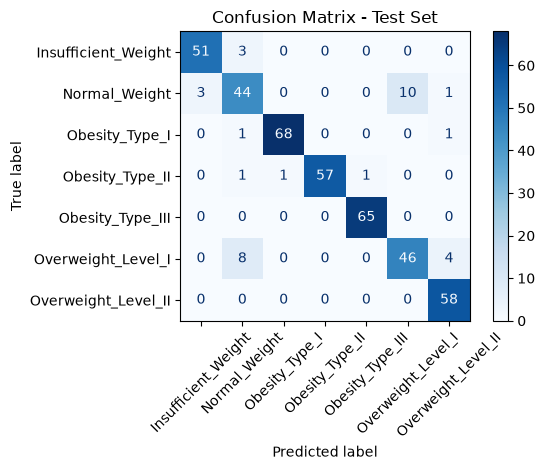

,Model,Test Accuracy,Test Macro-F1,Training Time (s),Parameters / Trees
0,Logistic Regression,0.888889,0.883878,Not recorded,140
1,Feedforward Neural Network,0.919622,0.916092,Not recorded,3591


In [25]:
# Part 2.5- Final Evaluation and showdown with Lab 2
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

best_model = FeedForwardNet(
    input_dim=input_dim,
    hidden_sizes=(64, 32),
    n_classes=7,
    dropout=0.0
).to(DEVICE)

best_model.load_state_dict(
    torch.load(
        "ffn_best.pt",
        map_location=DEVICE
    )
)

best_model.eval()

test_predictions = []
test_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        logits = best_model(xb)
        predictions = torch.argmax(logits, dim=1)

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        test_targets.extend(
            yb.cpu().numpy()
        )

test_predictions = np.array(test_predictions)
test_targets = np.array(test_targets)

test_accuracy = accuracy_score(
    test_targets,
    test_predictions
)

test_macro_f1 = f1_score(
    test_targets,
    test_predictions,
    average="macro"
)

print("Test Accuracy:", test_accuracy)
print("Test Macro-F1:", test_macro_f1)

class_names = label_e.classes_

print(
    classification_report(
        test_targets,
        test_predictions,
        target_names=class_names,
        digits=4
    )
)

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    test_targets,
    test_predictions,
    display_labels=label_e.classes_,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()


nn_parameters = sum(
    p.numel()
    for p in best_model.parameters()
    if p.requires_grad
)
logistic_parameters = len(label_e.classes_) * (X_train.shape[1] + 1)
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Feedforward Neural Network"
    ],
    "Test Accuracy": [
        0.8888888888888888,
        test_accuracy
    ],
    "Test Macro-F1": [
        0.8838779799778422,
        test_macro_f1
    ],
    "Training Time (s)": [
        "Not recorded",
        "Not recorded"
    ],
    "Parameters / Trees": [
        logistic_parameters,
        nn_parameters
    ]
})
comparison
